In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('features_weekly.csv')
print(f"Shape : {df.shape}")
df.head(3)

Shape : (284061, 86)


,user,week_start,week_number,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,...,z_http_avg_requests_per_day,z_http_upload_ratio,z_http_download_ratio,z_http_off_hours_ratio,z_http_suspicious_ratio,psycho_ocean_risk_score,ldap_zscore_departure,users_activity_not_main_pc_ratio,users_post_departure_activity,users_pre_departure_ratio
0,AAB0162,2010-01-04,1,0.222222,0.0,0.0,0.000000,0.0,0.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.062937,0.27574,0.0,0.0,0.0
1,AAB0162,2010-01-11,2,0.166667,0.0,0.0,0.011111,0.0,0.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.062937,0.27574,0.0,0.0,0.0
2,AAB0162,2010-01-18,3,0.229630,0.0,0.0,0.022222,0.0,0.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.062937,0.27574,0.0,0.0,0.0


In [4]:
threat_weeks = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')

if 'is_insider' in df.columns:
    df = df.drop(columns=['is_insider'])

threat_df = pd.DataFrame(threat_weeks, columns=['user', 'week_start'])
threat_df['is_insider'] = 1

df = df.merge(threat_df, on=['user', 'week_start'], how='left')
df['is_insider'] = df['is_insider'].fillna(0).astype(int)

print(df['is_insider'].value_counts())

is_insider
0    284040
1        21
Name: count, dtype: int64


In [5]:
COLS_TO_DROP = [
    'week_start', 'user', 'week_number', 'is_insider',
    'file_open_then_copy_ratio', 'file_copy_then_delete_ratio'
]

X = df.drop(columns=COLS_TO_DROP)


X_train = X[df['is_insider'] == 0].copy()
X_all   = X.copy()

print(f"Features : {X.shape[1]}")
print(f"Lignes train (non-insiders) : {len(X_train)}")
print(f"Lignes totales : {len(X_all)}")

Features : 81
Lignes train (non-insiders) : 284040
Lignes totales : 284061


In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns
)
X_all_scaled = pd.DataFrame(
    scaler.transform(X_all), columns=X.columns
)


X_tensor_train = torch.FloatTensor(X_train_scaled.values)
X_tensor_all   = torch.FloatTensor(X_all_scaled.values)

dataset = TensorDataset(X_tensor_train)
loader  = DataLoader(dataset, batch_size=64, shuffle=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_32732\1034416341.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_tensor_train = torch.FloatTensor(X_train_scaled.values)


In [9]:
class SkipVAE(nn.Module):
    def __init__(self, n_features, latent_dim=4):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(n_features, 48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
        )

        self.pre_bn = nn.Sequential(
            nn.Linear(24, 12),
            nn.ReLU(),
        )

        self.fc_mu     = nn.Linear(12, latent_dim)
        self.fc_logvar = nn.Linear(12, latent_dim)

       
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 12, 12),
            nn.ReLU(),
            nn.Linear(12, 24),
            nn.ReLU(),
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Linear(48, n_features),
        )

    def encode(self, x):
        h      = self.encoder(x)
        h_last = self.pre_bn(h)
        mu     = self.fc_mu(h_last)
        
        logvar = self.fc_logvar(h_last).clamp(-4.0, 4.0)
        return mu, logvar, h_last

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu   

    def forward(self, x):
        mu, logvar, h_last = self.encode(x)
        z     = self.reparameterize(mu, logvar)
        fused = torch.cat([z, h_last], dim=-1)  
        x_hat = self.decoder(fused)
        return x_hat, mu, logvar

In [ ]:
def vae_loss_free_bits(x, x_hat, mu, logvar, beta, lambda_fb=0.1):
    """
    Loss = MSE_recon + beta * KL_free_bits

    KL par dimension : -0.5 * (1 + logvar - mu² - exp(logvar))
    Free bits        : max(KL_dim, lambda_fb)  pour chaque dim latente
    """
    recon = F.mse_loss(x_hat, x, reduction='mean')

   
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())

  
    kl_per_dim_mean = kl_per_dim.mean(dim=0)          
    kl_free         = torch.clamp(kl_per_dim_mean, min=lambda_fb)
    kl              = kl_free.sum()

    total = recon + beta * kl
    return total, recon, kl


def get_beta(epoch, warmup_epochs, beta_max):
    """Montée linéaire de β de 0 à beta_max sur warmup_epochs."""
    if epoch >= warmup_epochs:
        return beta_max
    return beta_max * (epoch / warmup_epochs)

In [ ]:

EPOCHS        = 500
LR            = 1e-3
WEIGHT_DEC    = 1e-5
BETA_MAX      = 1.0    
WARMUP_EPOCHS = 150    
LAMBDA_FB     = 0.1    
LATENT_DIM    = 4

n_features = X.shape[1]
model      = SkipVAE(n_features=n_features, latent_dim=LATENT_DIM)
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DEC)

best_loss  = float('inf')
best_state = None
history    = {'total': [], 'recon': [], 'kl': [], 'beta': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_total = epoch_recon = epoch_kl = 0.0

    beta = get_beta(epoch, WARMUP_EPOCHS, BETA_MAX)

    for (batch,) in loader:
        x_hat, mu, logvar = model(batch)
        loss, recon, kl   = vae_loss_free_bits(
            batch, x_hat, mu, logvar,
            beta=beta, lambda_fb=LAMBDA_FB
        )
        optimizer.zero_grad()
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon.item()
        epoch_kl    += kl.item()

    n = len(loader)
    avg_total = epoch_total / n
    avg_recon = epoch_recon / n
    avg_kl    = epoch_kl    / n

    history['total'].append(avg_total)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)
    history['beta'].append(beta)

   
    if avg_recon < best_loss:
        best_loss  = avg_recon
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | β={beta:.3f} | "
              f"Total: {avg_total:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

model.load_state_dict(best_state)
print(f"\nMeilleur modèle restauré (recon={best_loss:.4f})")

Epoch    0 | β=0.000 | Total: 0.4574  Recon: 0.4574  KL: 47.9317
Epoch   50 | β=0.333 | Total: 0.3133  Recon: 0.1799  KL: 0.4001
Epoch  100 | β=0.667 | Total: 0.4396  Recon: 0.1729  KL: 0.4001
Epoch  150 | β=1.000 | Total: 0.5705  Recon: 0.1703  KL: 0.4002
Epoch  200 | β=1.000 | Total: 0.5693  Recon: 0.1691  KL: 0.4001
Epoch  250 | β=1.000 | Total: 0.5685  Recon: 0.1684  KL: 0.4001
Epoch  300 | β=1.000 | Total: 0.5674  Recon: 0.1672  KL: 0.4002
Epoch  350 | β=1.000 | Total: 0.5669  Recon: 0.1668  KL: 0.4000
Epoch  400 | β=1.000 | Total: 0.5669  Recon: 0.1668  KL: 0.4001
Epoch  450 | β=1.000 | Total: 0.5658  Recon: 0.1657  KL: 0.4001

Meilleur modèle restauré (recon=0.1647)


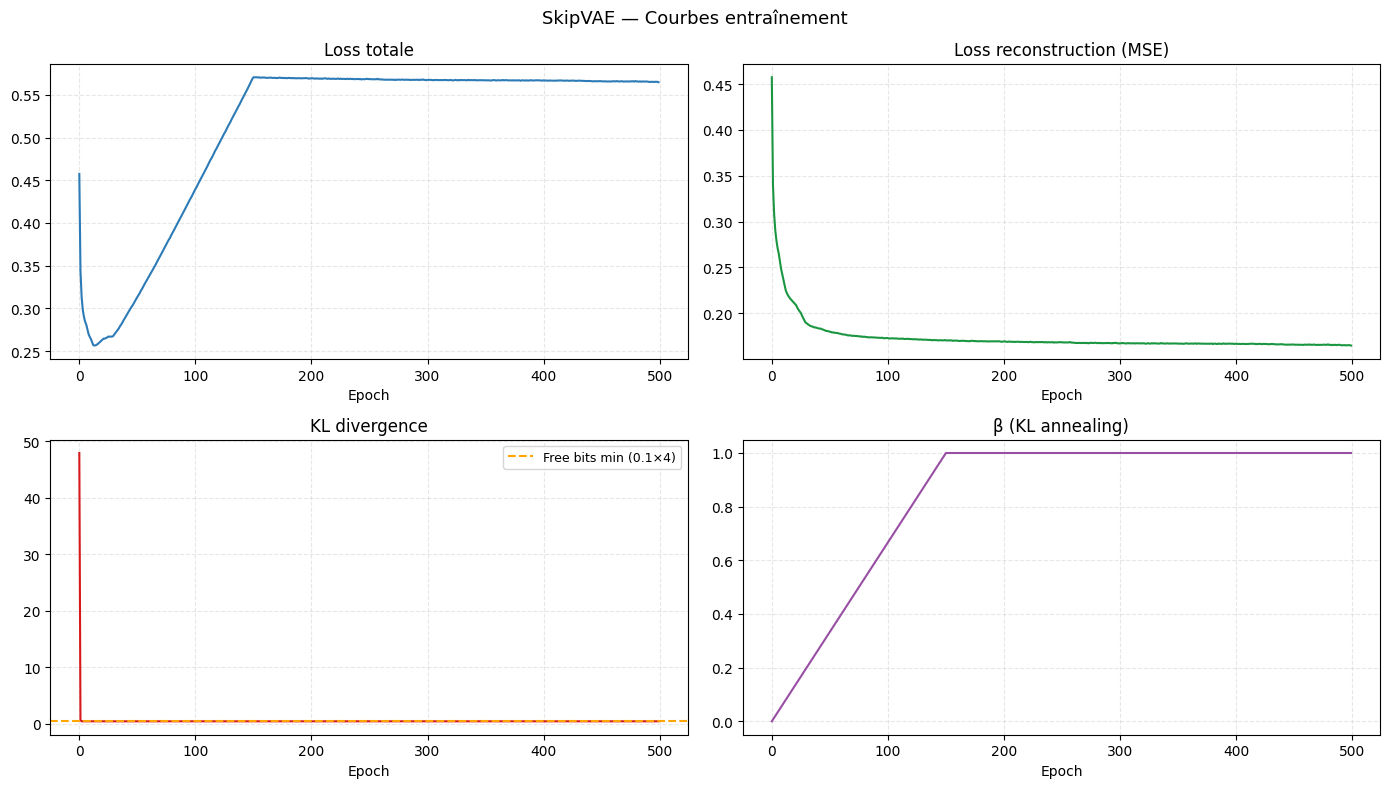

KL moyenne (20 dernières epochs) : 0.4001
OK : KL active, pas de posterior collapse


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(history['total'], color='#2c7bb6')
axes[0,0].set_title('Loss totale')
axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(history['recon'], color='#1a9641')
axes[0,1].set_title('Loss reconstruction (MSE)')
axes[0,1].set_xlabel('Epoch')

axes[1,0].plot(history['kl'], color='#d7191c')
axes[1,0].axhline(
    y=LAMBDA_FB * LATENT_DIM,
    color='orange', linestyle='--',
    label=f'Free bits min ({LAMBDA_FB}×{LATENT_DIM})'
)
axes[1,0].set_title('KL divergence')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend(fontsize=9)

axes[1,1].plot(history['beta'], color='#984ea3')
axes[1,1].set_title('β (KL annealing)')
axes[1,1].set_xlabel('Epoch')

for ax in axes.flat:
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('SkipVAE — Courbes entraînement', fontsize=13)
plt.tight_layout()
plt.show()

kl_final = np.mean(history['kl'][-20:])
print(f"KL moyenne (20 dernières epochs) : {kl_final:.4f}")
if kl_final < 0.05:
    print("ATTENTION : KL encore proche de 0 → augmenter LAMBDA_FB (essayer 0.5 ou 1.0)")
else:
    print("OK : KL active, pas de posterior collapse")

In [13]:
K = 200

model.eval()
with torch.no_grad():
    x_hat, mu, logvar = model(X_tensor_all)
    errors = torch.mean((X_tensor_all - x_hat) ** 2, dim=1).numpy()

df_scores = pd.DataFrame({
    'user'       : df['user'].values,
    'week_start' : df['week_start'].values,
    'is_insider' : df['is_insider'].values,
    'score'      : errors
})

df_scores = df_scores.sort_values('score', ascending=False).reset_index(drop=True)
df_scores['rank'] = range(1, len(df_scores) + 1)

df_insiders = df_scores[df_scores['is_insider'] == 1].copy()

print("=== Ranking des semaines insider ===")
print(df_insiders[['user', 'week_start', 'score', 'rank']].to_string(index=False))

top_k_hits = (df_insiders['rank'] <= K).sum()
mean_rank  = df_insiders['rank'].mean()
total      = len(df_scores)
n_insiders = len(df_insiders)

print(f"\n--- Métriques ---")
print(f"Top-{K} hit rate : {top_k_hits} / {n_insiders}  ({100*top_k_hits/n_insiders:.1f}%)")
print(f"Mean rank       : {mean_rank:.1f} / {total}")
print(f"Mean rank norm. : {mean_rank/total:.4f}")

=== Ranking des semaines insider ===
   user week_start     score   rank
ACM2278 2010-08-16 11.608641      8
PLJ1771 2010-08-09 11.437297      9
ACM2278 2010-08-23 10.744699     11
PLJ1771 2010-08-16  8.210479     19
CDE1846 2011-03-21  1.267036   1999
CDE1846 2011-04-11  1.183611   2307
CDE1846 2011-04-25  0.562520  13148
CMP2946 2011-03-07  0.415404  24532
CDE1846 2011-04-04  0.381454  28605
CMP2946 2011-03-28  0.365610  30830
CMP2946 2011-03-14  0.363359  31168
CMP2946 2011-03-21  0.360460  31611
CMP2946 2011-02-21  0.355185  32388
CMP2946 2011-02-14  0.327302  37007
CMP2946 2011-02-28  0.312890  39803
CMP2946 2011-01-31  0.289606  44682
CMP2946 2011-02-07  0.286541  45428
CDE1846 2011-03-14  0.274430  48432
CDE1846 2011-03-28  0.228525  61816
MBG3183 2010-10-11  0.228237  61927
CDE1846 2011-02-21  0.101356 125066

--- Métriques ---
Top-200 hit rate : 4 / 21  (19.0%)
Mean rank       : 31466.5 / 284061
Mean rank norm. : 0.1108


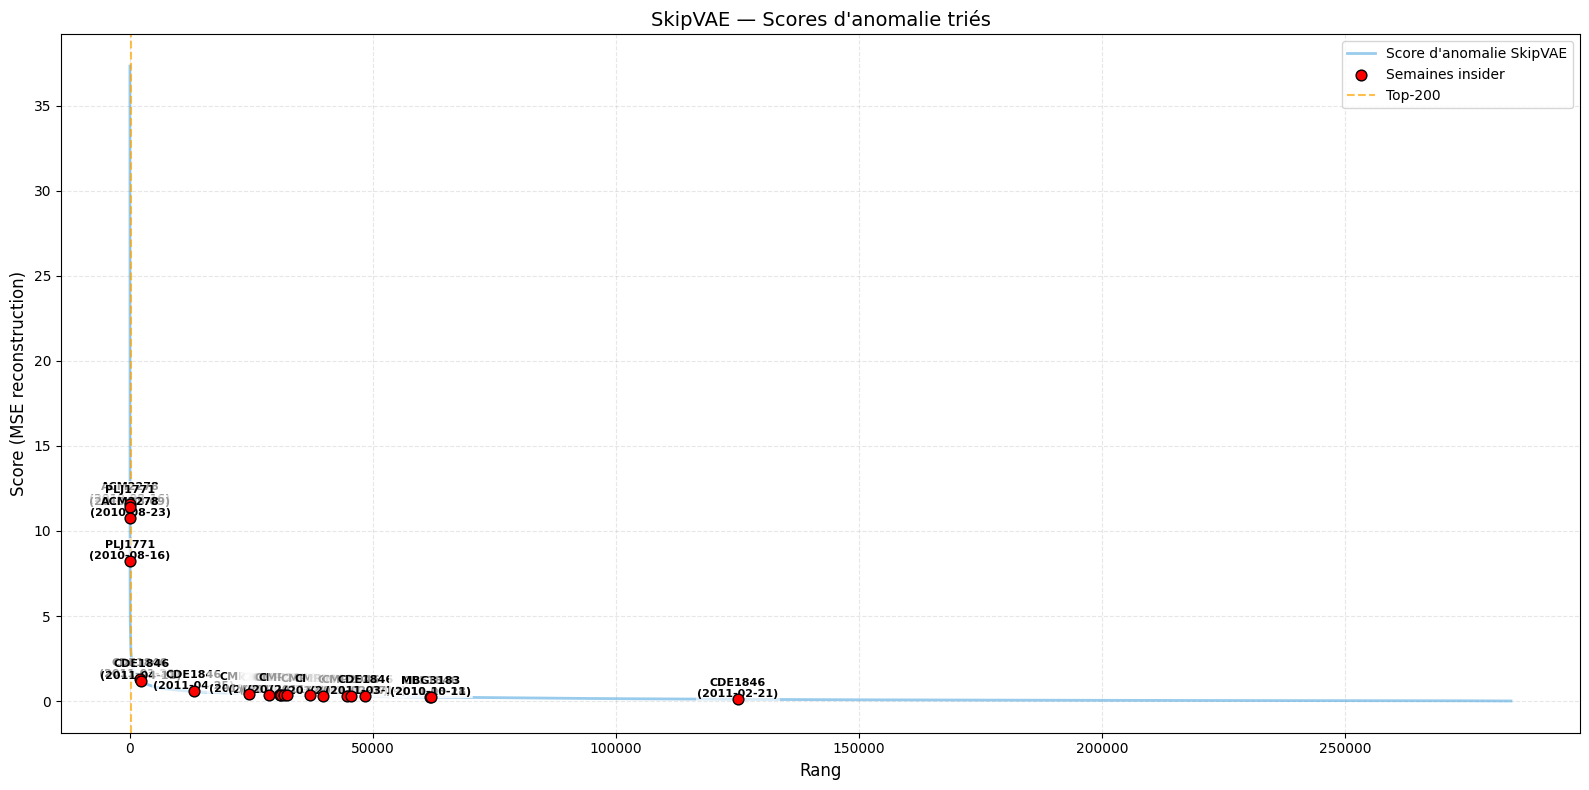

In [14]:
insider_indices = df_scores[df_scores['is_insider'] == 1].index

plt.figure(figsize=(16, 8))
plt.plot(
    df_scores.index, df_scores['score'],
    label="Score d'anomalie SkipVAE",
    color='#3498db', alpha=0.5, linewidth=2
)
if len(insider_indices) > 0:
    plt.scatter(
        insider_indices,
        df_scores.loc[insider_indices, 'score'],
        color='red', label='Semaines insider',
        s=60, zorder=5, edgecolors='black'
    )
    for idx in insider_indices:
        plt.text(
            idx, df_scores.loc[idx, 'score'],
            f"{df_scores.loc[idx,'user']}\n({df_scores.loc[idx,'week_start']})",
            fontsize=8, fontweight='bold',
            verticalalignment='bottom', horizontalalignment='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

plt.axvline(x=K, color='orange', linestyle='--', alpha=0.7, label=f'Top-{K}')
plt.title("SkipVAE — Scores d'anomalie triés", fontsize=14)
plt.xlabel("Rang", fontsize=12)
plt.ylabel("Score (MSE reconstruction)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

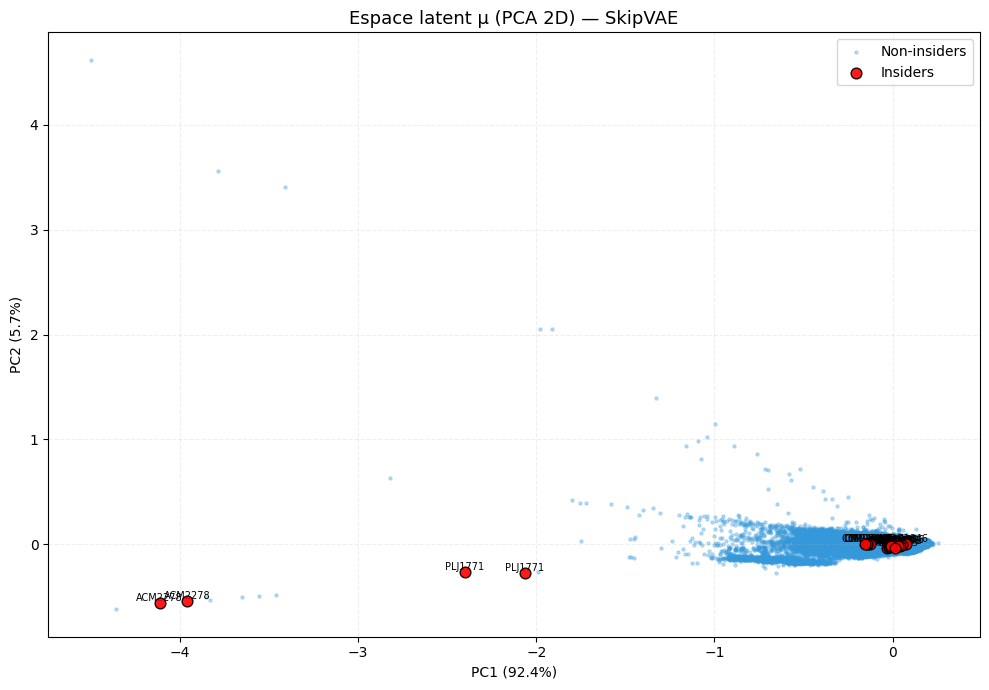

In [15]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    h      = model.encoder(X_tensor_all)
    h_last = model.pre_bn(h)
    mu_all = model.fc_mu(h_last).numpy()

pca = PCA(n_components=2)
mu_2d = pca.fit_transform(mu_all)

labels = df['is_insider'].values

plt.figure(figsize=(10, 7))
plt.scatter(
    mu_2d[labels == 0, 0], mu_2d[labels == 0, 1],
    s=5, alpha=0.3, color='#3498db', label='Non-insiders'
)
plt.scatter(
    mu_2d[labels == 1, 0], mu_2d[labels == 1, 1],
    s=60, alpha=0.9, color='red', edgecolors='black',
    zorder=5, label='Insiders'
)

insider_rows = df[df['is_insider'] == 1].reset_index()
for i, row in insider_rows.iterrows():
    orig_idx = row['index']
    plt.annotate(
        row['user'],
        (mu_2d[orig_idx, 0], mu_2d[orig_idx, 1]),
        fontsize=7, ha='center', va='bottom'
    )

plt.title('Espace latent μ (PCA 2D) — SkipVAE', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

## Améliorations

In [7]:
class SkipVAE(nn.Module):
    """
    SkipVAE v2
    ----------
    Encodeur : n -> 64 -> 48 -> 32 -> 16 (h_last)
    Latent   : fc_mu / fc_logvar  (dim = LATENT_DIM)
    Skip     : h_enc1 (64) concat au decodeur en entree
    Decodeur : (z + h_last + h_enc1) -> 32 -> 48 -> 64 -> n
    """
    def __init__(self, n_features, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim

        
        self.enc_block1 = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.enc_block2 = nn.Sequential(
            nn.Linear(64, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Linear(48, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )

        self.fc_mu     = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

       
        dec_input_dim = latent_dim + 16 + 64
        self.dec_block1 = nn.Sequential(
            nn.Linear(dec_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
        )
        self.dec_block2 = nn.Sequential(
            nn.Linear(48, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, n_features),
        )

    def encode(self, x):
        h_enc1 = self.enc_block1(x)          
        h_last = self.enc_block2(h_enc1)      
        mu     = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last).clamp(-6.0, 2.0)
        return mu, logvar, h_last, h_enc1

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):
        mu, logvar, h_last, h_enc1 = self.encode(x)
        z     = self.reparameterize(mu, logvar)
        
        fused = torch.cat([z, h_last, h_enc1], dim=-1)
        dec   = self.dec_block1(fused)
        x_hat = self.dec_block2(dec)
        return x_hat, mu, logvar

In [8]:
def vae_loss_free_bits(x, x_hat, mu, logvar, beta, lambda_fb=0.2):
    """
    Loss = MSE_recon + beta * KL_free_bits
    Free bits par dimension : max(KL_dim, lambda_fb)
    lambda_fb augmente a 0.2 pour garantir que toutes les dims latentes
    restent actives (evite le posterior collapse).
    """
    recon = F.mse_loss(x_hat, x, reduction='mean')

    kl_per_dim      = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_per_dim_mean = kl_per_dim.mean(dim=0)
    kl_free         = torch.clamp(kl_per_dim_mean, min=lambda_fb)
    kl              = kl_free.sum()

    total = recon + beta * kl
    return total, recon, kl


def get_beta(epoch, warmup_epochs, beta_max):
    """Montee lineaire de beta de 0 a beta_max sur warmup_epochs."""
    if epoch >= warmup_epochs:
        return beta_max
    return beta_max * (epoch / warmup_epochs)

In [11]:
EPOCHS        = 800          
LR            = 5e-4         
WEIGHT_DEC    = 1e-5
BETA_MAX      = 0.3          
WARMUP_EPOCHS = 200         
LAMBDA_FB     = 0.2         
LATENT_DIM    = 8           

n_features = X.shape[1]
model      = SkipVAE(n_features=n_features, latent_dim=LATENT_DIM)
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DEC)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

best_loss  = float('inf')
best_state = None
history    = {'total': [], 'recon': [], 'kl': [], 'beta': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_total = epoch_recon = epoch_kl = 0.0

    beta = get_beta(epoch, WARMUP_EPOCHS, BETA_MAX)

    for (batch,) in loader:
        x_hat, mu, logvar = model(batch)
        loss, recon, kl   = vae_loss_free_bits(
            batch, x_hat, mu, logvar,
            beta=beta, lambda_fb=LAMBDA_FB
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon.item()
        epoch_kl    += kl.item()

    n_batches = len(loader)
    avg_total = epoch_total / n_batches
    avg_recon = epoch_recon / n_batches
    avg_kl    = epoch_kl    / n_batches

    history['total'].append(avg_total)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)
    history['beta'].append(beta)

   
    scheduler.step(avg_recon)

    if avg_recon < best_loss:
        best_loss  = avg_recon
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | beta={beta:.3f} | ",
              f"Total: {avg_total:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

model.load_state_dict(best_state)
print(f"\nMeilleur modele restaure (recon={best_loss:.4f})")

Epoch    0 | beta=0.000 |  Total: 0.3444  Recon: 0.3444  KL: 2.7040
Epoch   50 | beta=0.075 |  Total: 0.1944  Recon: 0.0744  KL: 1.6000
Epoch  100 | beta=0.150 |  Total: 0.3138  Recon: 0.0738  KL: 1.6000
Epoch  150 | beta=0.225 |  Total: 0.4310  Recon: 0.0710  KL: 1.6000
Epoch  200 | beta=0.300 |  Total: 0.5496  Recon: 0.0696  KL: 1.6000
Epoch  250 | beta=0.300 |  Total: 0.5470  Recon: 0.0670  KL: 1.6000
Epoch  300 | beta=0.300 |  Total: 0.5479  Recon: 0.0679  KL: 1.6000
Epoch  350 | beta=0.300 |  Total: 0.5473  Recon: 0.0673  KL: 1.6000
Epoch  400 | beta=0.300 |  Total: 0.5447  Recon: 0.0647  KL: 1.6000
Epoch  450 | beta=0.300 |  Total: 0.5441  Recon: 0.0641  KL: 1.6000
Epoch  500 | beta=0.300 |  Total: 0.5445  Recon: 0.0645  KL: 1.6000
Epoch  550 | beta=0.300 |  Total: 0.5465  Recon: 0.0665  KL: 1.6000
Epoch  600 | beta=0.300 |  Total: 0.5437  Recon: 0.0637  KL: 1.6000
Epoch  650 | beta=0.300 |  Total: 0.5435  Recon: 0.0635  KL: 1.6000
Epoch  700 | beta=0.300 |  Total: 0.5457  Recon:

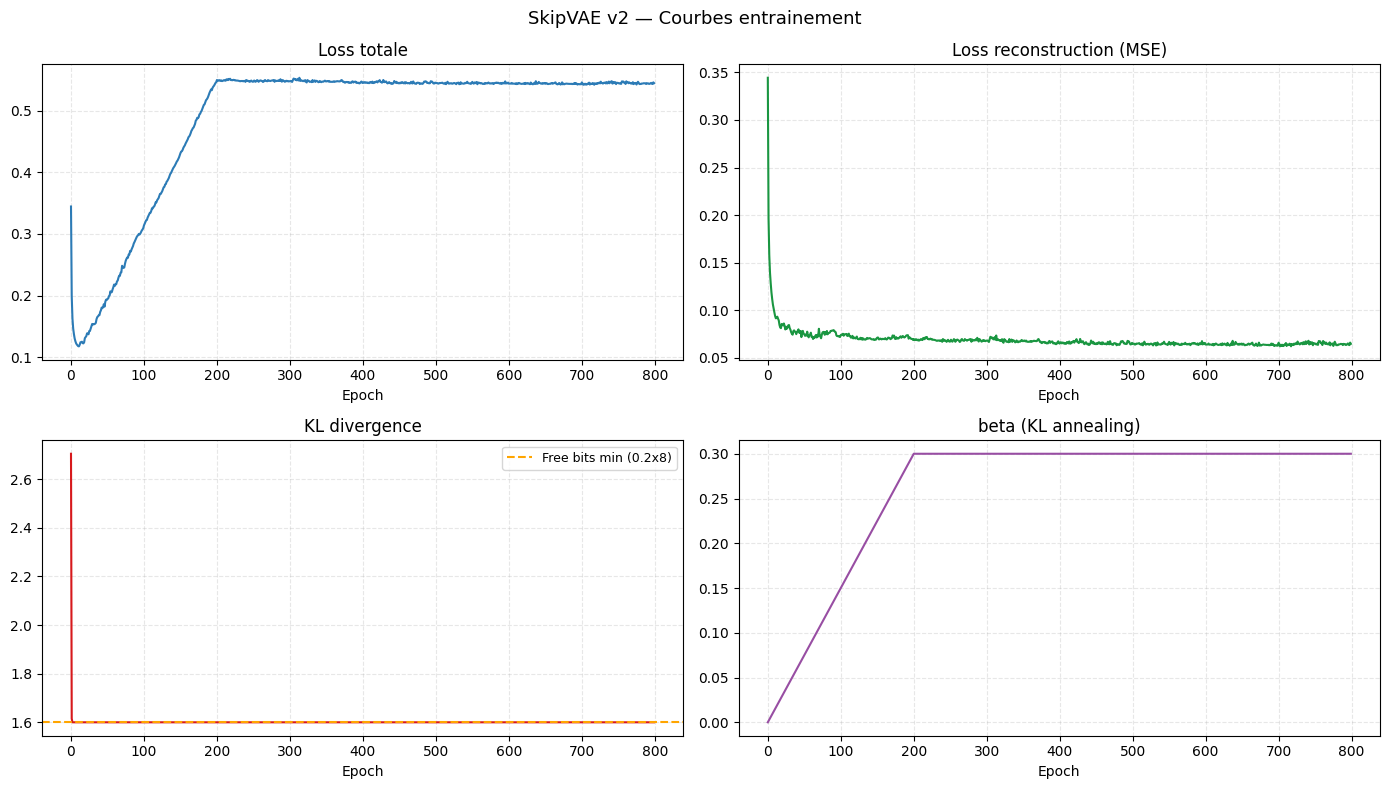

KL moyenne (20 dernieres epochs) : 1.6000
OK : KL active, pas de posterior collapse


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(history['total'], color='#2c7bb6')
axes[0,0].set_title('Loss totale')
axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(history['recon'], color='#1a9641')
axes[0,1].set_title('Loss reconstruction (MSE)')
axes[0,1].set_xlabel('Epoch')

axes[1,0].plot(history['kl'], color='#d7191c')
axes[1,0].axhline(
    y=LAMBDA_FB * LATENT_DIM,
    color='orange', linestyle='--',
    label=f'Free bits min ({LAMBDA_FB}x{LATENT_DIM})'
)
axes[1,0].set_title('KL divergence')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend(fontsize=9)

axes[1,1].plot(history['beta'], color='#984ea3')
axes[1,1].set_title('beta (KL annealing)')
axes[1,1].set_xlabel('Epoch')

for ax in axes.flat:
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('SkipVAE v2 — Courbes entrainement', fontsize=13)
plt.tight_layout()
plt.show()

kl_final = np.mean(history['kl'][-20:])
print(f"KL moyenne (20 dernieres epochs) : {kl_final:.4f}")
if kl_final < 0.05:
    print("ATTENTION : KL encore proche de 0 -> augmenter LAMBDA_FB (essayer 0.5 ou 1.0)")
else:
    print("OK : KL active, pas de posterior collapse")

In [13]:
K     = 25
ALPHA = 0.3   

model.eval()
with torch.no_grad():
    x_hat, mu, logvar = model(X_tensor_all)

   
    recon_errors = torch.mean((X_tensor_all - x_hat) ** 2, dim=1).numpy()

    
    kl_per_sample = (-0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(), dim=1
    )).numpy()
    kl_per_sample = np.clip(kl_per_sample, 0, None)  # KL >= 0

    # Normalisation separee avant fusion
    recon_norm = (recon_errors - recon_errors.min()) / (recon_errors.max() - recon_errors.min() + 1e-9)
    kl_norm    = (kl_per_sample - kl_per_sample.min()) / (kl_per_sample.max() - kl_per_sample.min() + 1e-9)

    scores = (1 - ALPHA) * recon_norm + ALPHA * kl_norm

df_scores = pd.DataFrame({
    'user'       : df['user'].values,
    'week_start' : df['week_start'].values,
    'is_insider' : df['is_insider'].values,
    'score'      : scores,
    'recon'      : recon_norm,
    'kl'         : kl_norm,
})

df_scores = df_scores.sort_values('score', ascending=False).reset_index(drop=True)
df_scores['rank'] = range(1, len(df_scores) + 1)

df_insiders = df_scores[df_scores['is_insider'] == 1].copy()

print("=== Ranking des semaines insider ===")
print(df_insiders[['user', 'week_start', 'score', 'recon', 'kl', 'rank']].to_string(index=False))

top_k_hits = (df_insiders['rank'] <= K).sum()
mean_rank  = df_insiders['rank'].mean()
total      = len(df_scores)
n_insiders = len(df_insiders)


users_in_topK = df_insiders[df_insiders['rank'] <= K]['user'].nunique()
total_insider_users = df_insiders['user'].nunique()

print(f"\n--- Metriques ---")
print(f"Top-{K} hit rate (semaines) : {top_k_hits} / {n_insiders}  ({100*top_k_hits/n_insiders:.1f}%)")
print(f"Top-{K} users detectes      : {users_in_topK} / {total_insider_users}")
print(f"Mean rank                   : {mean_rank:.1f} / {total}")
print(f"Mean rank norm.             : {mean_rank/total:.4f}")

=== Ranking des semaines insider ===
   user week_start    score        recon       kl   rank
ACM2278 2010-08-23 0.131838 1.281396e-01 0.140469      8
ACM2278 2010-08-16 0.125016 1.213066e-01 0.133672     10
PLJ1771 2010-08-16 0.006914 3.425650e-03 0.015055     42
PLJ1771 2010-08-09 0.000233 1.050576e-04 0.000531   3010
CMP2946 2011-01-31 0.000020 3.832527e-07 0.000066   6448
CMP2946 2011-02-07 0.000020 3.833313e-07 0.000066   6457
CMP2946 2011-02-28 0.000020 3.878454e-07 0.000065   6654
CMP2946 2011-03-28 0.000020 4.239480e-07 0.000065   6782
CMP2946 2011-02-14 0.000020 3.744906e-07 0.000065   6785
CMP2946 2011-02-21 0.000020 3.811573e-07 0.000065   6815
CMP2946 2011-03-21 0.000020 4.149778e-07 0.000064   6956
CMP2946 2011-03-14 0.000019 4.112129e-07 0.000064   7127
CMP2946 2011-03-07 0.000019 3.807812e-07 0.000063   7647
MBG3183 2010-10-11 0.000014 2.463304e-07 0.000047  79117
CDE1846 2011-02-21 0.000014 2.559463e-08 0.000045 103032
CDE1846 2011-04-04 0.000013 3.601704e-08 0.000043 1

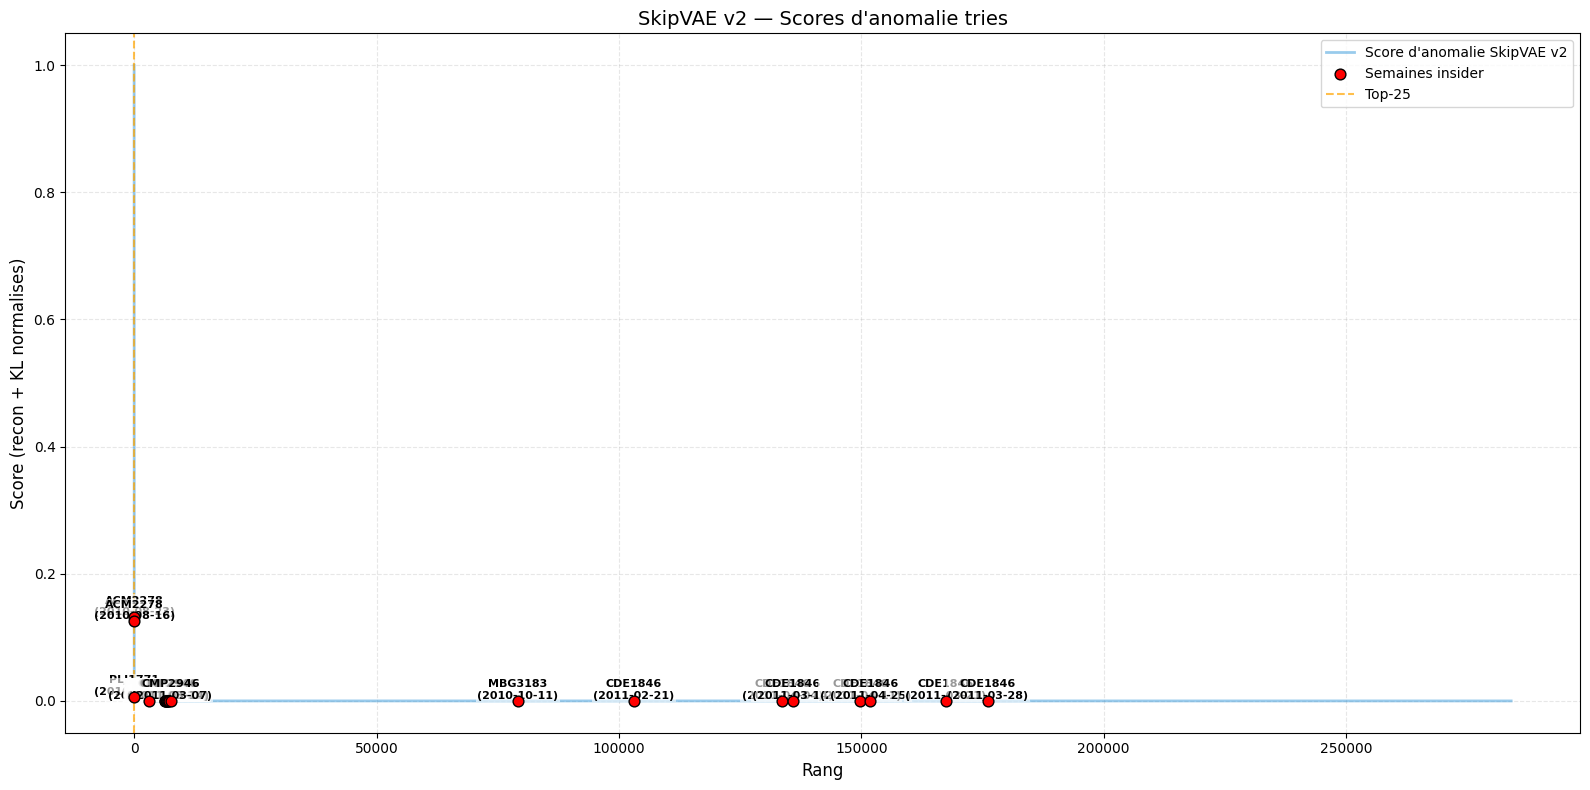

In [14]:
insider_indices = df_scores[df_scores['is_insider'] == 1].index

plt.figure(figsize=(16, 8))
plt.plot(
    df_scores.index, df_scores['score'],
    label="Score d'anomalie SkipVAE v2",
    color='#3498db', alpha=0.5, linewidth=2
)
if len(insider_indices) > 0:
    plt.scatter(
        insider_indices,
        df_scores.loc[insider_indices, 'score'],
        color='red', label='Semaines insider',
        s=60, zorder=5, edgecolors='black'
    )
    for idx in insider_indices:
        plt.text(
            idx, df_scores.loc[idx, 'score'],
            f"{df_scores.loc[idx,'user']}\n({df_scores.loc[idx,'week_start']})",
            fontsize=8, fontweight='bold',
            verticalalignment='bottom', horizontalalignment='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

plt.axvline(x=K, color='orange', linestyle='--', alpha=0.7, label=f'Top-{K}')
plt.title("SkipVAE v2 — Scores d'anomalie tries", fontsize=14)
plt.xlabel("Rang", fontsize=12)
plt.ylabel("Score (recon + KL normalises)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()